<a href="https://colab.research.google.com/github/ananiaanand/catvsdog/blob/main/CatvsDog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"anania2007","key":"6533f6aa9791bf84141a5aaa059d1447"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c dogs-vs-cats

100% 812M/812M [00:08<00:00, 100MB/s]



In [ ]:
!unzip -q dogs-vs-cats.zip -d dataset

In [ ]:
!unzip -q dataset/test1.zip -d dataset


In [ ]:
!unzip -q dataset/train.zip -d dataset

In [ ]:
import os
import cv2
import numpy as np

def load_images(folder, limit = 25000):
  images =[]
  labels = []
  for idx, filename in enumerate(os.listdir(folder)):
    if idx == limit:
      break
    img_path = os.path.join(folder, filename)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
      label = 0 if 'cat' in filename else 1
      img = cv2.resize(img, (64,64))
      img = img / 255.0  # Normalize pixel values to 0-1 range
      images.append(img.flatten())
      labels.append(label)
  return np.array(images), np.array(labels)

In [ ]:
X, Y = load_images('dataset/train', limit = 25000)

In [ ]:
X.shape

(25000, 4096)

In [ ]:
import matplotlib.pyplot as plt
def show_images(img, labels, no_of_images):
  plt.figure(figsize(10,5))
  for i in range(no_of_images):
    plt.subplot(1, no_of_images, i+1)
    plt.imread(img[i].reshape(64,64), cmap = 'gray')
    plt.title('Dog' if labels[i] == 1 else 'Cat')
    plt.axis('off')
  plt.show()

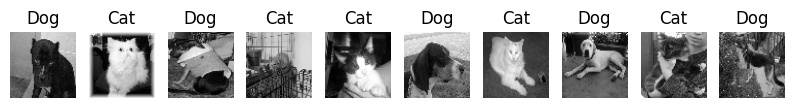

In [ ]:
import matplotlib.pyplot as plt

def show_images(img, labels, no_of_images):
  plt.figure(figsize=(10,5)) # Corrected figsize syntax
  for i in range(no_of_images):
    plt.subplot(1, no_of_images, i+1)
    plt.imshow(img[i].reshape(64,64), cmap = 'gray') # Corrected to imshow
    plt.title('Dog' if labels[i] == 1 else 'Cat')
    plt.axis('off')
  plt.show()

show_images(X,Y, 10)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [ ]:
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)


(20000, 4096) (20000,) (5000, 4096) (5000,)


In [ ]:
model = XGBClassifier()
model.fit(X_train, Y_train)
train_data_prediction = model.predict(X_train)
train_accuracy = accuracy_score(train_data_prediction, Y_train)
print(train_accuracy)

0.99385


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize XGBClassifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=xgb_model,
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=3, # Using 3-fold cross-validation
                           verbose=1,
                           n_jobs=-1) # Use all available cores

# Fit GridSearchCV to the training data
grid_search.fit(X_train, Y_train)

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: ", grid_search.best_score_)


In [ ]:
# Evaluate the best model on the test data
best_model = grid_search.best_estimator_
test_predictions = best_model.predict(X_test)
test_accuracy = accuracy_score(Y_test, test_predictions)
print("Test accuracy with best parameters: ", test_accuracy)


In [ ]:
def predict_image(image_path, model):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        img = cv2.resize(img, (64, 64))
        img_flat = img.flatten().reshape(1, -1)  # Reshape for single prediction
        prediction = model.predict(img_flat)
        return 'Cat' if prediction[0] == 0 else 'Dog'
    else:
        return "Error: Could not load image."

test_data_prediction = model.predict(X_test)
train_accuracy = accuracy_score(test_data_prediction, Y_test)
print(train_accuracy)
result = predict_image('dog.jpg', model)
print(result)

0.651
Cat
